# Determining the initial labeled pool size

In [8]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Support running the notebook either from its own directory or the repository root.
experiment_dir = Path.cwd()
if not (experiment_dir / "determine_initial_pool.ipynb").exists():
    experiment_dir = experiment_dir / "experiments" / "1_determine_initial_pool"

records = []
for loss_path in sorted((experiment_dir / "runs").glob("f3ed_initial_pool_only_*_seed*/round_000/loss.json")):
    run_dir = loss_path.parents[1]
    with (run_dir / "config.json").open() as file:
        config = json.load(file)
    with loss_path.open() as file:
        losses = json.load(file)

    for row in losses:
        records.append({
            "run": run_dir.name,
            "pool_size": float(config["initial_labeled_pool_size"]),
            "seed": int(config["seed"]),
            "epoch": int(row["epoch"]),
            "train": float(row["train"]),
            "val": float(row["val"]),
            "val_edit": float(row.get("val_edit", np.nan)),
        })

loss_df = pd.DataFrame.from_records(records)
if loss_df.empty:
    raise FileNotFoundError(f"No run loss files found in {experiment_dir.resolve()}")
loss_df = loss_df.sort_values(["pool_size", "seed", "epoch"]).reset_index(drop=True)

pool_sizes = sorted(loss_df["pool_size"].unique())
colors = dict(zip(pool_sizes, plt.cm.viridis(np.linspace(0.1, 0.9, len(pool_sizes)))))

def plot_loss(metric, title):
    fig, ax = plt.subplots(figsize=(10, 6))

    for pool_size, pool_data in loss_df.groupby("pool_size", sort=True):
        color = colors[pool_size]
        for _, run_data in pool_data.groupby("run"):
            ax.plot(run_data["epoch"], run_data[metric], color=color, alpha=0.18, linewidth=1)

        summary = pool_data.groupby("epoch")[metric].agg(["mean", "std"]).reset_index()
        std = summary["std"].fillna(0)
        label = f"{pool_size:g}% ({pool_data['run'].nunique()} seeds)"
        ax.plot(summary["epoch"], summary["mean"], color=color, linewidth=2.5, label=label)
        ax.fill_between(
            summary["epoch"], summary["mean"] - std, summary["mean"] + std,
            color=color, alpha=0.12, linewidth=0,
        )

    ax.set(title=title, xlabel="Epoch", ylabel="Loss")
    ax.grid(alpha=0.25)
    ax.legend(title="Initial labeled pool")
    fig.tight_layout()
    return fig, ax

print(f"Loaded {loss_df['run'].nunique()} runs from {experiment_dir.resolve()}")

Loaded 50 runs from /mnt/ssd2/zachary/alpes/experiments/1_determine_initial_pool


## Training Loss

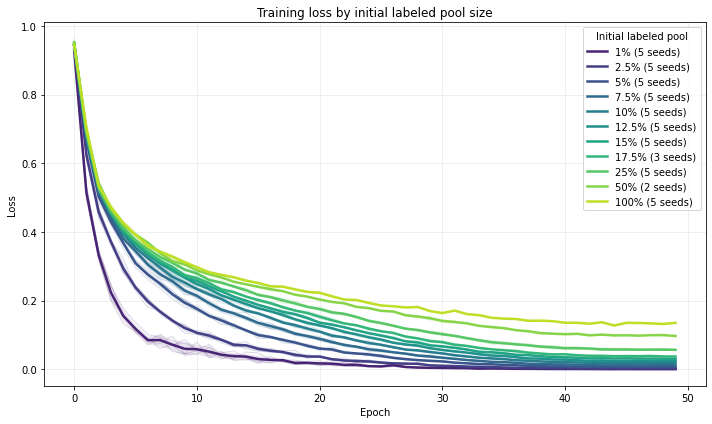

In [9]:
plot_loss("train", "Training loss by initial labeled pool size");

## Validation Loss

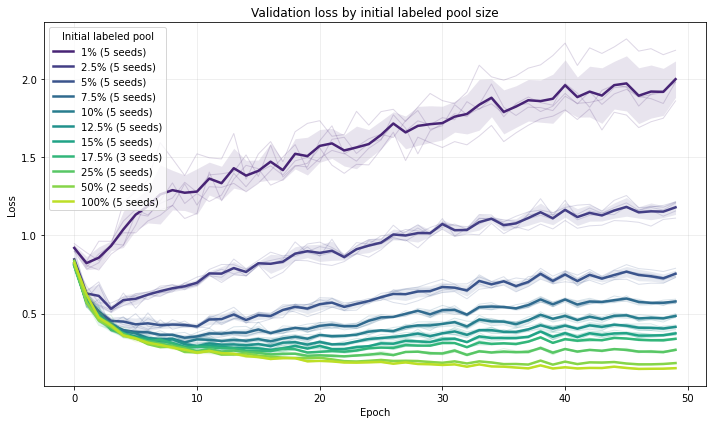

In [10]:
plot_loss("val", "Validation loss by initial labeled pool size");

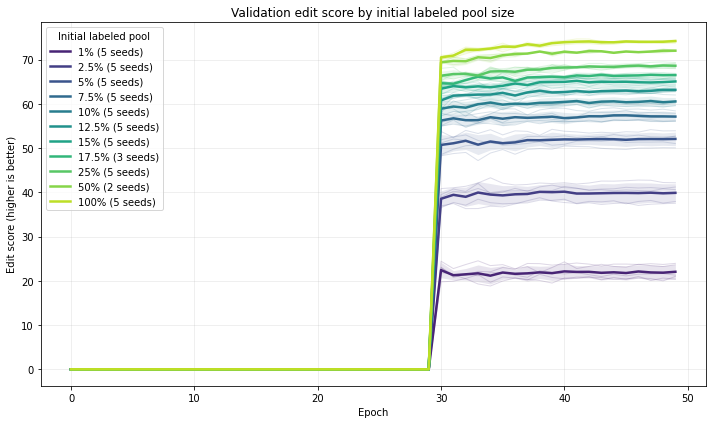

In [11]:
plot_loss("val_edit", "Validation edit score by initial labeled pool size")[1].set_ylabel("Edit score (higher is better)");

## Budget-performance trade-off

The final checkpoint summaries are more directly useful for choosing an initial pool than loss alone. Points show individual seeds; error bars are approximate 95% confidence intervals around the mean. The 15% result currently has only one seed and should be treated as provisional. Validation edit is the selection metric; test edit is shown only as a confirmation signal.

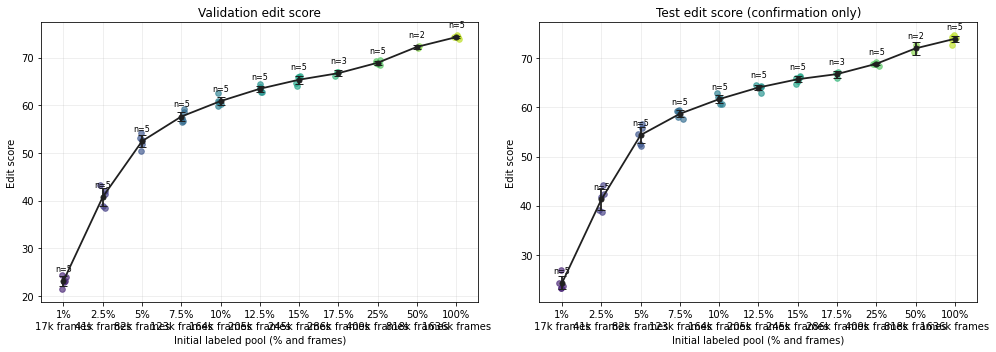

In [12]:
metric_records = []
for run in loss_df["run"].unique():
    run_dir = experiment_dir / "runs" / run
    with (run_dir / "config.json").open() as file:
        config = json.load(file)
    with (run_dir / "history.json").open() as file:
        result = json.load(file)[0]
    metric_records.append({
        "run": run,
        "pool_size": float(config["initial_labeled_pool_size"]),
        "seed": int(config["seed"]),
        "labeled_samples": int(result["labeled_pool_size"]),
        "labeled_frames": int(result["labeled_pool_frames"]),
        "best_epoch": int(result["best_epoch"]),
        "val_edit": float(result["val_edit"]),
        "test_edit": float(result["test_edit"]),
    })

metric_df = pd.DataFrame(metric_records).sort_values(["pool_size", "seed"])
summary = (metric_df.groupby("pool_size")
           .agg(n_seeds=("seed", "count"),
                labeled_samples=("labeled_samples", "mean"),
                labeled_frames=("labeled_frames", "mean"),
                val_mean=("val_edit", "mean"), val_std=("val_edit", "std"),
                test_mean=("test_edit", "mean"), test_std=("test_edit", "std"),
                best_epoch_mean=("best_epoch", "mean"))
           .reset_index())
summary["val_ci95"] = 1.96 * summary["val_std"] / np.sqrt(summary["n_seeds"])
summary["test_ci95"] = 1.96 * summary["test_std"] / np.sqrt(summary["n_seeds"])

positions = np.arange(len(summary))
tick_labels = [f"{p:g}%\n{f / 1000:.0f}k frames" for p, f in
               zip(summary["pool_size"], summary["labeled_frames"])]
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
rng = np.random.default_rng(7)
for ax, metric, mean_col, ci_col, title in [
    (axes[0], "val_edit", "val_mean", "val_ci95", "Validation edit score"),
    (axes[1], "test_edit", "test_mean", "test_ci95", "Test edit score (confirmation only)"),
]:
    for x, (_, group) in zip(positions, metric_df.groupby("pool_size", sort=True)):
        jitter = rng.uniform(-0.08, 0.08, len(group))
        ax.scatter(x + jitter, group[metric], color=colors[group["pool_size"].iloc[0]],
                   alpha=0.65, s=32, zorder=2)
    ax.errorbar(positions, summary[mean_col], yerr=summary[ci_col], color="#202020",
                marker="o", markersize=5, linewidth=1.8, capsize=4, zorder=3)
    for x, row in summary.iterrows():
        ax.annotate(f"n={int(row['n_seeds'])}", (x, row[mean_col]), xytext=(0, 10),
                    textcoords="offset points", ha="center", fontsize=8)
    ax.set(title=title, xlabel="Initial labeled pool (% and frames)", ylabel="Edit score")
    ax.set_xticks(positions, tick_labels)
    ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Stability and diminishing returns

The heatmap exposes seed sensitivity and missing runs. The marginal-gain chart pairs the same seed at adjacent tested pool sizes, then divides the edit-score improvement by the additional labeled percentage points. A falling gain indicates diminishing returns; an interval crossing zero means the apparent improvement is not reliable with the current runs. The jump from 15% to 100% is omitted because it spans too broad a range to locate an elbow.

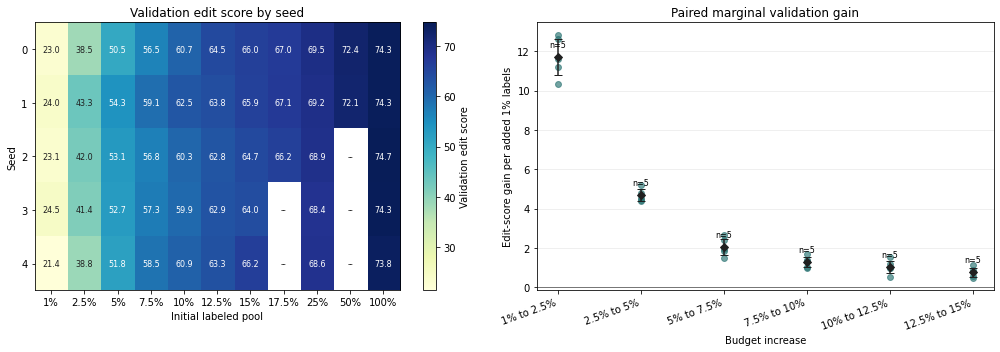

In [13]:
heatmap = metric_df.pivot(index="seed", columns="pool_size", values="val_edit")
small_pools = [p for p in heatmap.columns if p <= 15]
gain_rows = []
for lower, upper in zip(small_pools[:-1], small_pools[1:]):
    paired = (metric_df[metric_df["pool_size"].isin([lower, upper])]
              .pivot(index="seed", columns="pool_size", values="val_edit")
              .dropna(subset=[lower, upper]))
    for seed, row in paired.iterrows():
        gain_rows.append({"step": f"{lower:g}% to {upper:g}%", "seed": seed,
                          "gain_per_pct": (row[upper] - row[lower]) / (upper - lower)})
gain_df = pd.DataFrame(gain_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
image = axes[0].imshow(heatmap, aspect="auto", cmap="YlGnBu")
axes[0].set(title="Validation edit score by seed", xlabel="Initial labeled pool", ylabel="Seed")
axes[0].set_xticks(range(len(heatmap.columns)), [f"{p:g}%" for p in heatmap.columns])
axes[0].set_yticks(range(len(heatmap.index)), heatmap.index)
for i, seed in enumerate(heatmap.index):
    for j, pool in enumerate(heatmap.columns):
        value = heatmap.loc[seed, pool]
        axes[0].text(j, i, "--" if pd.isna(value) else f"{value:.1f}",
                     ha="center", va="center", fontsize=8,
                     color="white" if pd.notna(value) and value > 0.65 * np.nanmax(heatmap.values) else "#202020")
fig.colorbar(image, ax=axes[0], label="Validation edit score")

steps = gain_df["step"].drop_duplicates().tolist()
for x, step in enumerate(steps):
    values = gain_df.loc[gain_df["step"] == step, "gain_per_pct"]
    axes[1].scatter(np.full(len(values), x), values, alpha=0.65, s=35, color="#287271")
    mean, std = values.mean(), values.std()
    ci = 1.96 * std / np.sqrt(len(values)) if len(values) > 1 else np.nan
    axes[1].errorbar(x, mean, yerr=ci, marker="D", color="#202020", capsize=4, zorder=3)
    axes[1].annotate(f"n={len(values)}", (x, mean), xytext=(0, 10),
                     textcoords="offset points", ha="center", fontsize=8)
axes[1].axhline(0, color="#777777", linewidth=1)
axes[1].set(title="Paired marginal validation gain", xlabel="Budget increase",
            ylabel="Edit-score gain per added 1% labels")
axes[1].set_xticks(range(len(steps)), steps, rotation=20, ha="right")
axes[1].grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

## Candidate summary

`test_vs_full_pct` reports how much of the 100%-pool test score is retained. Prefer validation statistics when choosing a budget, and reserve test performance for the final confirmation. A practical initial-pool candidate should combine acceptable performance, low seed variability, and a low marginal return from moving to the next larger pool.

In [14]:
full_test_mean = summary.loc[summary["pool_size"] == summary["pool_size"].max(), "test_mean"].iloc[0]
summary["test_vs_full_pct"] = 100 * summary["test_mean"] / full_test_mean
summary["marginal_val_gain_per_pct"] = (
    summary["val_mean"].diff() / summary["pool_size"].diff()
)
candidate_summary = summary[[
    "pool_size", "n_seeds", "labeled_samples", "labeled_frames",
    "val_mean", "val_std", "val_ci95", "test_mean", "test_std",
    "test_vs_full_pct", "marginal_val_gain_per_pct", "best_epoch_mean",
]].copy()
candidate_summary["labeled_samples"] = candidate_summary["labeled_samples"].round().astype(int)
candidate_summary["labeled_frames"] = candidate_summary["labeled_frames"].round().astype(int)
candidate_summary.style.format({
    "pool_size": "{:.1f}%", "val_mean": "{:.2f}", "val_std": "{:.2f}",
    "val_ci95": "{:.2f}", "test_mean": "{:.2f}", "test_std": "{:.2f}",
    "test_vs_full_pct": "{:.1f}%", "marginal_val_gain_per_pct": "{:.2f}",
    "best_epoch_mean": "{:.1f}",
}).background_gradient(subset=["val_mean", "test_vs_full_pct"], cmap="YlGn")

,pool_size,n_seeds,labeled_samples,labeled_frames,val_mean,val_std,val_ci95,test_mean,test_std,test_vs_full_pct,marginal_val_gain_per_pct,best_epoch_mean
0,1.0%,5,78,16591,23.20,1.20,1.05,24.29,1.53,32.8%,nan,33.4
1,2.5%,5,189,41010,40.78,2.09,1.83,41.26,2.34,55.8%,11.72,35.6
2,5.0%,5,376,81912,52.47,1.41,1.24,54.37,1.93,73.5%,4.68,43.2
3,7.5%,5,568,122813,57.63,1.14,1.00,58.70,0.81,79.4%,2.06,42.8
4,10.0%,5,755,163677,60.87,1.00,0.88,61.68,0.97,83.4%,1.30,39.8
5,12.5%,5,943,204652,63.45,0.72,0.63,64.04,0.68,86.6%,1.03,41.6
6,15.0%,5,1120,245498,65.36,0.95,0.84,65.73,0.65,88.9%,0.76,41.2
7,17.5%,3,1307,286372,66.72,0.50,0.56,66.77,0.65,90.3%,0.55,46.3
8,25.0%,5,1862,409044,68.91,0.45,0.39,68.87,0.29,93.1%,0.29,44.6
9,50.0%,2,3718,817980,72.23,0.25,0.34,72.01,0.90,97.4%,0.13,44.0


## Current reading

- **10% and 12.5% are the strongest primary candidates.** Both have five seeds, relatively low variation, and retain roughly 83% and 87% of full-data test performance, respectively. Use both if the active-learning budget permits a small initial-pool ablation; use 10% if preserving acquisition budget is the priority.
- **5% is a useful data-starved stress test**, but its validation score is about 8.4 points below 10% and its seed variability is higher.
- **15% is promising but not decision-ready.** Its single run scores above 12.5%, so complete the remaining seeds before treating that gain as reliable.
- **The 15%-to-100% gap is too wide to identify a later elbow.** If larger initial pools are affordable, add replicated 20% and 25% runs before considering anything substantially above 15%.